# Distribuição de Frequência

## Slides teoria

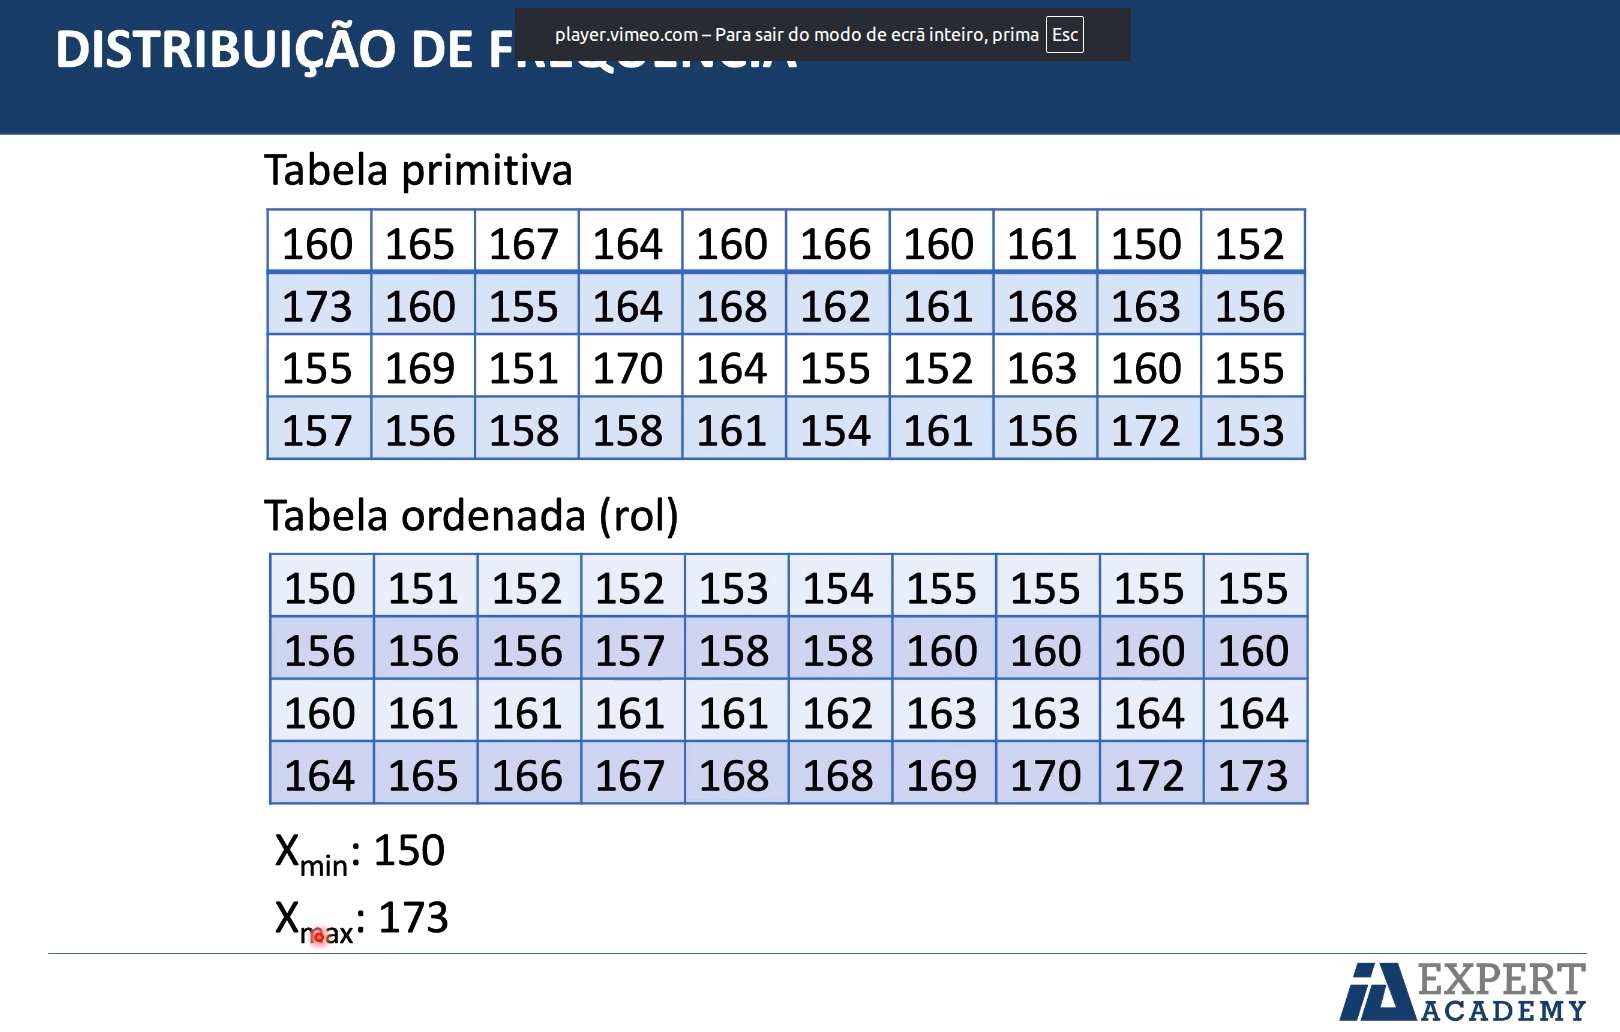

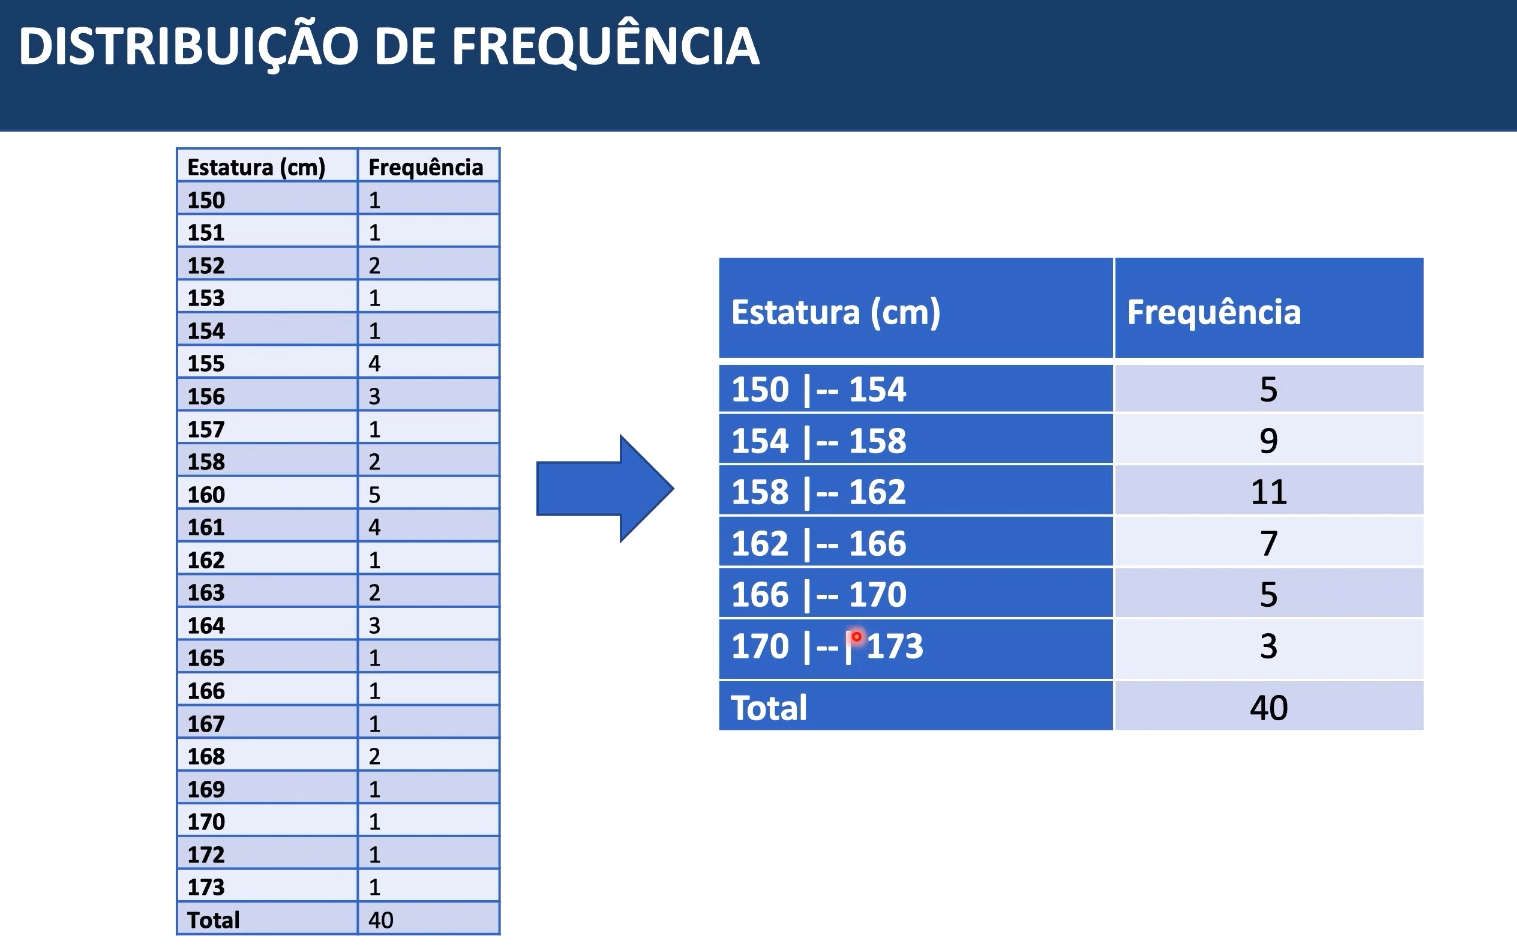

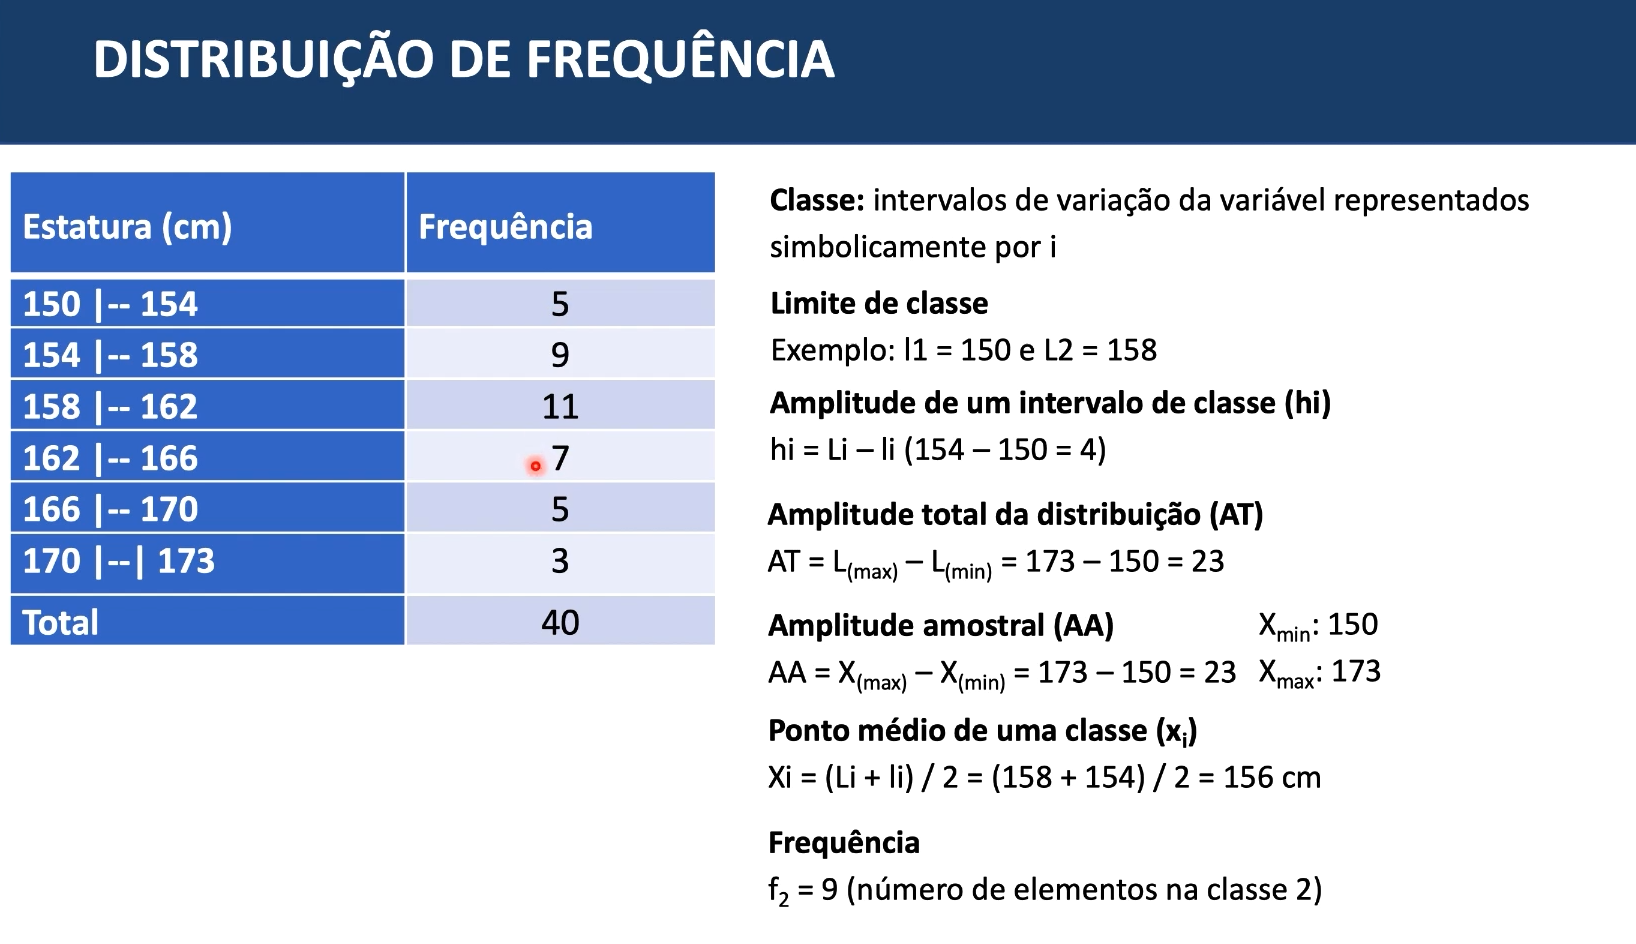

## Implementação

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [36]:
dados = np.array([160, 165, 167, 164, 160, 166, 160, 161, 150, 152, 173, 160, 155,
                    164, 168, 162, 161, 168, 163, 156, 155, 169, 151, 170, 164, 
                    155, 152, 163, 160, 155, 157, 156, 158, 158, 161, 154, 161, 156, 172, 153])

### Ordenação (rol)

In [37]:
dados = np.sort(dados)
dados

array([150, 151, 152, 152, 153, 154, 155, 155, 155, 155, 156, 156, 156,
       157, 158, 158, 160, 160, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 164, 164, 164, 165, 166, 167, 168, 168, 169, 170, 172,
       173])

In [38]:
minimo = dados.min()
minimo

np.int64(150)

In [39]:
maximo = dados.max()
maximo

np.int64(173)

In [40]:
np.unique(dados, return_counts=True)


(array([150, 151, 152, 153, 154, 155, 156, 157, 158, 160, 161, 162, 163,
        164, 165, 166, 167, 168, 169, 170, 172, 173]),
 array([1, 1, 2, 1, 1, 4, 3, 1, 2, 5, 4, 1, 2, 3, 1, 1, 1, 2, 1, 1, 1, 1]))

<BarContainer object of 40 artists>

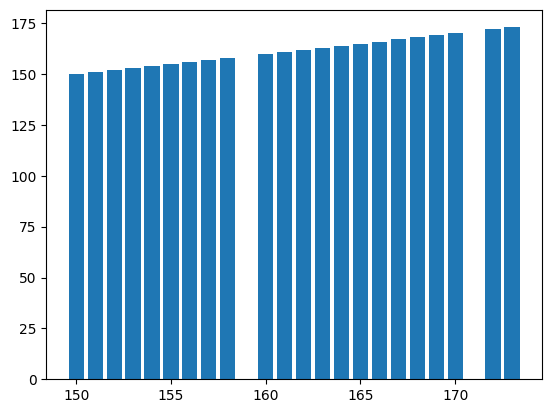

In [41]:
plt.bar(dados, dados)

### Número de classes
- i = 1 + 3.3 log n

In [42]:
n = len(dados)
n

40

In [43]:
i = 1 + 3.3 * np.log10(n)
i

np.float64(6.286797971382276)

In [44]:
i = round(i)
i

6

### Amplitude do intervalo
- h = AA / i
- AA = Xmax - Xmin

In [45]:
AA = maximo - minimo
AA

np.int64(23)

In [46]:
h = AA / i
h

np.float64(3.8333333333333335)

In [47]:
import math
h = math.ceil(h)
h

4

### Construção da distribuição de frequência

In [48]:
intervalos = np.arange(minimo, maximo+2, step=h)
intervalos

array([150, 154, 158, 162, 166, 170, 174])

In [49]:
intervalo1, intervalo2, intervalo3, intervalo4, intervalo5, intervalo6 = 0,0,0,0,0,0

for i in range(n):
    if dados[i] >= intervalos[0] and dados[i] < intervalos[1]:
        intervalo1 += 1
    elif dados[i] >= intervalos[1] and dados[i] < intervalos[2]:
        intervalo2 += 1
    elif dados[i] >= intervalos[2] and dados[i] < intervalos[3]:
        intervalo3 += 1
    elif dados[i] >= intervalos[3] and dados[i] < intervalos[4]:
        intervalo4 +=1
    elif dados[i] >= intervalos[4] and dados[i] < intervalos[5]:
        intervalo5 +=1
    else:
        intervalo6 +=1


In [50]:
lista_intervalos = [intervalo1, intervalo2, intervalo3, intervalo4, intervalo5, intervalo6]
lista_intervalos


[5, 9, 11, 7, 5, 3]

In [51]:
lista_classes = []
for i in range(len(lista_intervalos)):
    lista_classes.append(str(intervalos[i]) + '-' + str(intervalos[i+1]))

lista_classes

['150-154', '154-158', '158-162', '162-166', '166-170', '170-174']

Text(0, 0.5, 'valores')

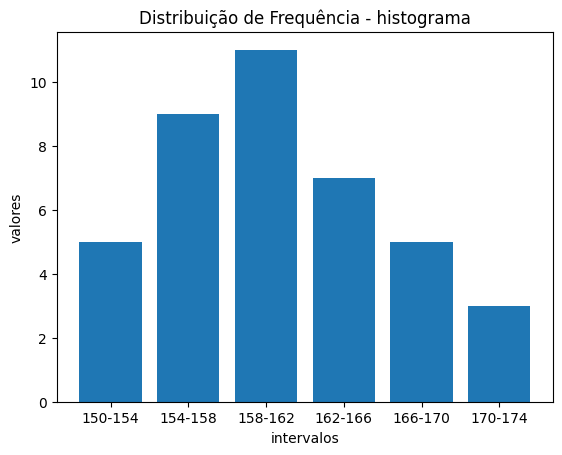

In [52]:
plt.bar(lista_classes, lista_intervalos)
plt.title('Distribuição de Frequência - histograma')
plt.xlabel('intervalos')
plt.ylabel('valores')

### Distribuição de frequência e histograma com numpy e matplotlib

In [62]:
dados = np.array([160, 165, 167, 164, 160, 166, 160, 161, 150, 152, 173, 160, 155,
                    164, 168, 162, 161, 168, 163, 156, 155, 169, 151, 170, 164, 
                    155, 152, 163, 160, 155, 157, 156, 158, 158, 161, 154, 161, 156, 172, 153])

In [63]:
frequencia, classes = np.histogram(dados)
frequencia, classes, len(classes)

(array([4, 2, 7, 3, 9, 3, 5, 3, 2, 2]),
 array([150. , 152.3, 154.6, 156.9, 159.2, 161.5, 163.8, 166.1, 168.4,
        170.7, 173. ]),
 11)

(array([4., 2., 7., 3., 9., 3., 5., 3., 2., 2.]),
 array([150. , 152.3, 154.6, 156.9, 159.2, 161.5, 163.8, 166.1, 168.4,
        170.7, 173. ]),
 <BarContainer object of 10 artists>)

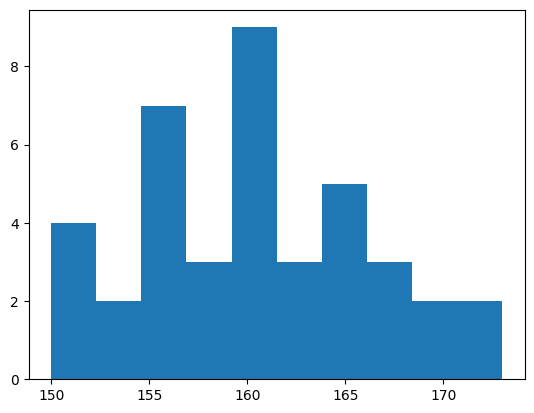

In [64]:
plt.hist(dados, bins=classes)

In [65]:
frequencia, classes = np.histogram(dados, bins=5)
frequencia, classes, len(classes)

(array([ 6, 10, 12,  8,  4]),
 array([150. , 154.6, 159.2, 163.8, 168.4, 173. ]),
 6)

(array([ 6., 10., 12.,  8.,  4.]),
 array([150. , 154.6, 159.2, 163.8, 168.4, 173. ]),
 <BarContainer object of 5 artists>)

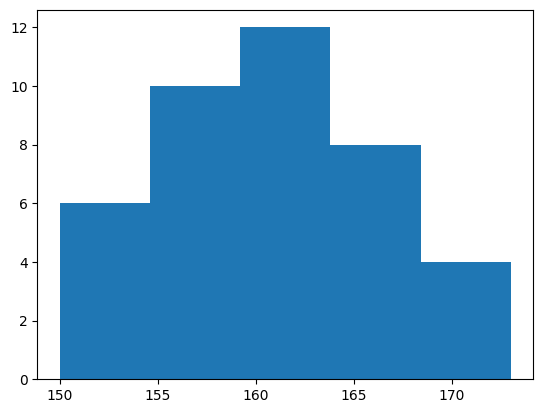

In [66]:
plt.hist(dados, bins=classes)

In [67]:
frequencia, classes = np.histogram(dados, bins = 'sturges')
frequencia, classes, len(classes)

(array([ 5,  8,  3, 12,  5,  4,  3]),
 array([150.        , 153.28571429, 156.57142857, 159.85714286,
        163.14285714, 166.42857143, 169.71428571, 173.        ]),
 8)

(array([ 5.,  8.,  3., 12.,  5.,  4.,  3.]),
 array([150.        , 153.28571429, 156.57142857, 159.85714286,
        163.14285714, 166.42857143, 169.71428571, 173.        ]),
 <BarContainer object of 7 artists>)

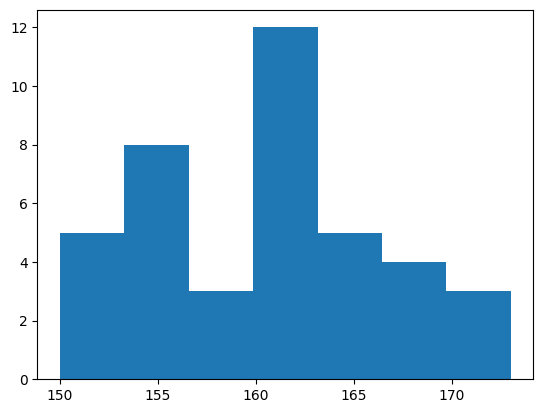

In [68]:
plt.hist(dados, classes)

### Distribuição de frequeência e histograma com pandas e seaborn

In [ ]:
dataset = pd.DataFrame({'dados': dados})
dataset

<Axes: ylabel='Frequency'>

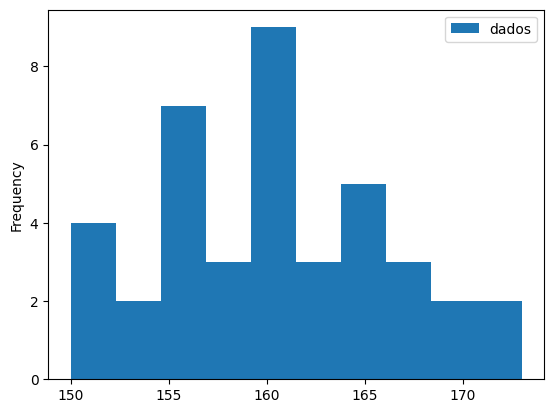

In [71]:
dataset.plot.hist()

/tmp/ipykernel_11292/2425563881.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dados)


<Axes: ylabel='Density'>

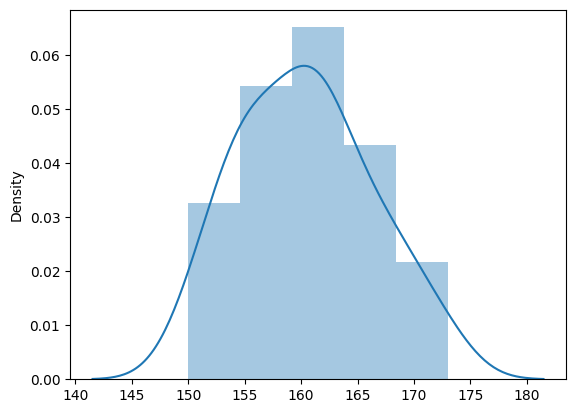

In [72]:
sns.distplot(dados)

<Axes: ylabel='Count'>

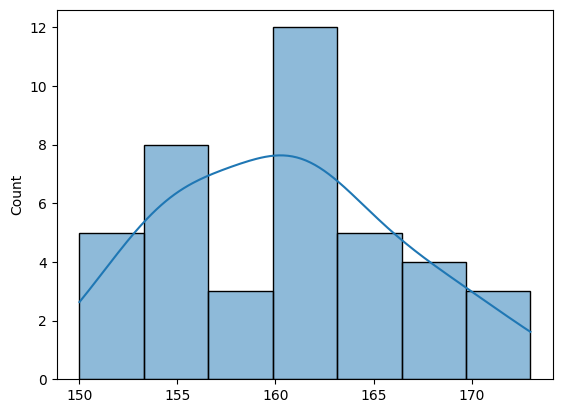

In [76]:
sns.histplot(dados, kde=True)